In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.sample(5, random_state=15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
310,311,1,1,"Hays, Miss. Margaret Bechstein",female,24.0,0,0,11767,83.1583,C54,C
635,636,1,2,"Davis, Miss. Mary",female,28.0,0,0,237668,13.0000,NaN,S
44,45,1,3,"Devaney, Miss. Margaret Delia",female,19.0,0,0,330958,7.8792,NaN,Q
698,699,0,1,"Thayer, Mr. John Borland",male,49.0,1,1,17421,110.8833,C68,C
750,751,1,2,"Wells, Miss. Joan",female,4.0,1,1,29103,23.0000,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


* **Veri Boyutu:** 891 satır ve 11 sütun.
* **Eksik Değerler:** Age, Embarked ve Cabin sütunlarında null (boş) veriler mevcut. Eksik verilerin yönetilmesi gerekiyor.

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Titanic veri setindeki sütunların kısa açıklamaları şöyledir:

* **PassengerId:** Yolcuya özel kimlik numarası.
* **Survived:** Hayatta kalma durumu (0 = Hayır, 1 = Evet).
* **Pclass:** Bilet sınıfı (1 = Üst, 2 = Orta, 3 = Alt).
* **Name:** Yolcunun adı ve unvanı.
* **Sex:** Cinsiyet.
* **Age:** Yaş.
* **SibSp:** Gemideki kardeş veya eş sayısı.
* **Parch:** Gemideki ebeveyn veya çocuk sayısı.
* **Ticket:** Bilet numarası.
* **Fare:** Bilet ücreti.
* **Cabin:** Kabin numarası.
* **Embarked:** Biniş limanı (C = Cherbourg, Q = Queenstown, S = Southampton).

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* **Yaş (Age):** 0.42 ile 80 yaş arası geniş bir dağılım var. Ortalama 29.69; yolcuların büyük çoğunluğu 15-43 yaş aralığında yoğunlaşıyor.
* **Refakatçi Durumu (SibSp & Parch):** Her iki sütunda da ortalamalar oldukça düşük (0.52 ve 0.38). Bu durum, yolcuların büyük bir kısmının gemiye tek başına bindiğini gösteriyor.
* **Bilet Ücreti (Fare):** 0 ile 512 birim arası çok geniş bir aralık var. Ortalama (32.2) ile maksimum değer (512.3) arasındaki büyük fark ve yüksek standart sapma (49.69), veride **aykırı değerlerin (outliers)** olduğuna işaret ediyor.
* **Ücretsiz Biletler:** Ücreti 0 olan kayıtlar, çalışanları veya özel geçişli yolcuları temsil ediyor olabilir.

In [7]:
df.describe(include="O")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


* **Cinsiyet Dağılımı:** Yolcuların çoğunluğu erkektir (**577** erkek). Bu durumun hayatta kalma oranları (Survived) üzerindeki etkisi kritik bir analiz noktasıdır.
* **Bilet ve Grup Analizi:** 891 satıra karşın 681 benzersiz bilet (Ticket) değeri olması, birden fazla yolcunun aynı biletle seyahat ettiğini (aile veya arkadaş grubu) gösterir.

    *Aksiyon:* Ücretin (Fare) kişi başı mı yoksa grup toplamı mı olduğu incelenmeli ve "Yalnız" veya "Grup" seyahat durumunu belirten yeni bir değişken (**Feature Engineering**) oluşturulmalıdır.



* **Kabin (Cabin) Verisi ve Eksik Değer Yönetimi:** Bazı yolcuların aynı kabini paylaştığı görülmektedir. Eksik kabin verileri, bilet numarası ve ücret benzerliklerine göre anlamlandırılmaya çalışılabilir.
* *Strateji:* "En sık tekrar eden değer" (Mode) ile doldurmak bu sütun için uygun değildir. Diğer sütunlarla anlamlı bir korelasyon kurulamazsa, veri setinden çıkarılması (Drop) değerlendirilmelidir.


* **Biniş Limanı (Embarked):** Yolcuların büyük bir kısmı gemiye **S (Southampton)** limanından binmiştir.


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Eksik Verilerin Yüzdesi:\n")
print(missing_percentage.sort_values(ascending=False))

Eksik Verilerin Yüzdesi:

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


### Eksik Veri Tamamlama Stratejileri

* **Liman (Embarked):** Eksik değerler %0.2 gibi az olduğu için, veri setinde en çok tekrar eden liman (**Mode**) ile doldurulmalı.
* **Yaş (Age):** Sabit bir ortalama yerine; **Pclass** (Sınıf) ve **Sex** (Cinsiyet) değişkenlerine göre gruplandırılarak (**Groupby**) bu grupların kendi ortalamalarıyla tamamlanmalı.
* **Kabin (Cabin):** Benzersiz değerleri incelenerek **Pclass** ve **Fare** (Ücret) ile ilişkisi kontrol edilmeli; eğer anlamlı bir ilişki bulunursa bu sütunlara göre tahminleme yapılmalı, bulunamazsa sütun droplanmalı.


### Survived (Hayatta Kalma)

In [10]:
survived_counts = df["Survived"].value_counts().sort_index()

fig = make_subplots(
    rows=1, cols=1,
    specs=[[{"type": "domain"}]]
)

fig.add_trace(
    go.Pie(
        labels=["Hayatta Kalmadı (0)", "Hayatta Kaldı (1)"],
        values=survived_counts.values,
        textinfo="label+percent",
        marker=dict(colors=["red", "green"]),
        hovertemplate="%{label}<br>Sayı: %{value}<br>Yüzde: %{percent}<extra></extra>"
    ),
    row=1, col=1
)

fig.update_layout(title_text="Titanic - Hayatta Kalma Oranı (Dairesel Grafik)")
fig.show()

Yolcuların çoğunluğu hayatta kalmadı. (%61.6)

### Sex (Cinsiyet)

In [11]:
sex_counts = df["Sex"].value_counts().sort_index()

fig = make_subplots(
    rows=1, cols=1,
    specs=[[{"type": "domain"}]],
)

fig.add_trace(
    go.Pie(
        labels=sex_counts.index,
        values=sex_counts.values,
        textinfo="label+percent",
        marker=dict(colors=["#ff69b4", "#1f77b4"]),
        hovertemplate="%{label}<br>Sayı: %{value}<br>Yüzde: %{percent}<extra></extra>"
    ),
    row=1, col=1
)

fig.update_layout(title_text="Titanic - Cinsiyet Dağılımı (Dairesel Grafik)")
fig.show()

Yolcuların çoğunluğu erkek. (%64.8)

### Pclass (Bilet Sınıfı)

In [12]:
pclass_counts = df["Pclass"].value_counts().sort_index()
pclass_percent = (pclass_counts / len(df)) * 100

fig = go.Figure(
    data=[
        go.Bar(
            x=pclass_percent.index.astype(str),
            y=pclass_percent.values,
            marker_color=["green", "orange", "red"],  # 1, 2, 3
            text=[f"%{p:.1f}" for p in pclass_percent.values],  # sadece yüzde görünsün
            textposition="outside",
            customdata=pclass_counts.values,  # count bilgisini hover için taşı
            hovertemplate="Pclass: %{x}<br>Yüzde: %{y:.1f}%<br>Count: %{customdata}<extra></extra>"
        )
    ]
)

fig.update_layout(
    title="Pclass Dağılımı (Yüzdesel)",
    xaxis_title="Pclass",
    yaxis_title="Yüzde (%)",
    yaxis_range=[0, pclass_percent.max() + 8]
)

fig.show()

* Yolcuların neredeyse yarısı "3. sınıf" yolcu. (%55.1)
* 1 ve 2. sınıf yakın

### Embarked (Binilen Liman)

In [13]:
embarked_order = ["S", "C", "Q"]
embarked_counts = df["Embarked"].value_counts().reindex(embarked_order, fill_value=0)
embarked_percent = (embarked_counts / len(df)) * 100

fig = go.Figure(
    data=[
        go.Bar(
            x=embarked_percent.index,
            y=embarked_percent.values,
            marker_color=["#636EFA", "#EF553B", "#00CC96"],  # yeni renkler
            text=[f"%{p:.1f}" for p in embarked_percent.values],
            textposition="outside",
            customdata=embarked_counts.values,
            hovertemplate="Embarked: %{x}<br>Yüzde: %{y:.1f}%<br>Count: %{customdata}<extra></extra>"
        )
    ]
)

fig.update_layout(
    title="Embarked Dağılımı (Yüzdesel)",
    xaxis_title="Embarked",
    yaxis_title="Yüzde (%)",
    yaxis_range=[0, embarked_percent.max() + 8]
)

fig.show()

* Yolcuların çok büyük bir çoğunluğu  S (Southampton) Limanından biniş yaptı. (%72.3)
* En az Q (Queenstown) limanından yolcu bindi. (%8.6)
* C (Cherbourg) (%18.9)

### Age (Yaş)

In [14]:
import plotly.figure_factory as ff

# age_data tanımlı değilse df'den üret (uyarıyı önler)
age_data = df["Age"].dropna()

# Distplot
dist_fig = ff.create_distplot(
    hist_data=[age_data],
    group_labels=["Age"],
    show_hist=True,
    show_rug=False,
    bin_size=5
)

# Özet istatistikler
stats = age_data.describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)
stat_names_tr = ["Count", "Mean", "Std", "Min", "25%", "Median", "75%", "Max"]

# 1 satır, 3 sütun: Distplot + Boxplot + Tablo
fig = make_subplots(
    rows=1, cols=3,
    column_widths=[0.60, 0.20, 0.20],
    specs=[[{"type": "xy"}, {"type": "xy"}, {"type": "table"}]],
    horizontal_spacing=0.04
)

# Distplot trace'leri (sol)
for trace in dist_fig.data:
    fig.add_trace(trace, row=1, col=1)

# Boxplot (orta)
fig.add_trace(
    go.Box(
        y=age_data,
        name="Age Boxplot",
        marker_color="#636EFA",
        boxmean="sd"
    ),
    row=1, col=2
)

# Özet tablo (sağ)
fig.add_trace(
    go.Table(
        header=dict(
            values=["<b>İstatistik</b>", "<b>Değer</b>"],
            fill_color="#E5ECF6",
            align="left"
        ),
        cells=dict(
            values=[stat_names_tr, stats.values],
            align="left"
        )
    ),
    row=1, col=3
)

fig.update_layout(
    title="Titanic - Yaş Dağılımı (Histogram + KDE + Boxplot + Özet Tablo)",
    template="plotly_white",
    showlegend=False
)

fig.update_xaxes(title_text="Yaş", row=1, col=1)
fig.update_yaxes(title_text="Yoğunluk", row=1, col=1)

fig.update_xaxes(title_text="", row=1, col=2)
fig.update_yaxes(title_text="Yaş", row=1, col=2)

fig.show()

* **Yaş Dağılımı:** Veri **sağa çarpıktır (pozitif skew)**. Ortalama yaş 29.7 iken, medyan yaş 28'dır.
* **Yoğunluk:** Gemideki yolcuların %50'si **20.12 - 38 yaş** aralığındaki genç yetişkinlerdir.
* **Özel Gruplar:** Çocuk, orta yaş ve yaşlılalrın verilerinin birbiine yakın olduğunu görüyoruz bu yüzden yeni bir sütun yaratmak mantıklı olabilir.
* **Aykırı Değerler (Outliers):** Boxplot'a göre **66 yaş üstü** yolcular istatistiksel olarak aykırı değer kabul edilmektedir. Kullanılacak makine öğrenmesi algoritmasına göre bu değerler yeniden ölçeklendirilebilir veya olduğu gibi bırakılabilir.

In [15]:
# Yaş aralıklarını (bins) ve bunlara karşılık gelen değerleri (labels) belirliyoruz
yas_araliklari = [0, 12, 20, 36, 57, 80]
kategoriler = [1, 2, 3, 4, 5]

# Yeni 'AgeGroup' sütununu oluşturuyoruz
df['AgeGroup'] = pd.cut(df['Age'], bins=yas_araliklari, labels=kategoriler)

# Sonucu kontrol edelim
print(df[['Age', 'AgeGroup']].sample(10, random_state=72))

      Age AgeGroup
9    14.0        2
450  36.0        3
306   NaN      NaN
179  36.0        3
346  40.0        4
616  34.0        3
516  34.0        3
851  74.0        5
811  39.0        4
794  25.0        3


### Fare (Ücret)

In [16]:
# Fare verisini hazırla
fare_data = df["Fare"].dropna()

# Distplot
dist_fig = ff.create_distplot(
    hist_data=[fare_data],
    group_labels=["Fare"],
    show_hist=True,
    show_rug=False,
    bin_size=10
)

# Özet istatistikler
stats = fare_data.describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)
stat_names_tr = ["Count", "Mean", "Std", "Min", "25%", "Median", "75%", "Max"]

# 1 satır, 3 sütun: Distplot + Boxplot + Tablo
fig = make_subplots(
    rows=1, cols=3,
    column_widths=[0.60, 0.20, 0.20],
    specs=[[{"type": "xy"}, {"type": "xy"}, {"type": "table"}]],
    horizontal_spacing=0.04
)

# Distplot trace'leri (sol)
for trace in dist_fig.data:
    fig.add_trace(trace, row=1, col=1)

# Boxplot (orta)
fig.add_trace(
    go.Box(
        y=fare_data,
        name="Fare Boxplot",
        marker_color="#EF553B",
        boxmean="sd"
    ),
    row=1, col=2
)

# Özet tablo (sağ)
fig.add_trace(
    go.Table(
        header=dict(
            values=["<b>İstatistik</b>", "<b>Değer</b>"],
            fill_color="#E5ECF6",
            align="left"
        ),
        cells=dict(
            values=[stat_names_tr, stats.values],
            align="left"
        )
    ),
    row=1, col=3
)

fig.update_layout(
    title="Titanic - Fare Dağılımı (Histogram + KDE + Boxplot + Özet Tablo)",
    template="plotly_white",
    showlegend=False
)

fig.update_xaxes(title_text="Fare", row=1, col=1)
fig.update_yaxes(title_text="Yoğunluk", row=1, col=1)

fig.update_xaxes(title_text="", row=1, col=2)
fig.update_yaxes(title_text="Fare", row=1, col=2)

fig.show()

In [17]:
print(df['Fare'].nlargest(5))

258    512.3292
679    512.3292
737    512.3292
27     263.0000
88     263.0000
Name: Fare, dtype: float64


* Çok net biçimde grafikte ilk gördüğümüz aykırı değerdir bu yüzden veri net gözükmemektedir. 
* "Fare" sütununun en büyük 5 değerini sıralayınca 512'den çok keskin olarak 263'e geçtiği görülür.
* Bu yüzden 512 ayrkırı değerinden net olarak temizlenmelidir.

In [18]:
df = df[df["Fare"] <= 500].reset_index(drop=True)

print(df['Fare'].nlargest(5))

27     263.000
88     263.000
340    263.000
437    263.000
310    262.375
Name: Fare, dtype: float64


In [19]:
# Fare verisini hazırla
fare_data = df["Fare"].dropna()

# Distplot
dist_fig = ff.create_distplot(
    hist_data=[fare_data],
    group_labels=["Fare"],
    show_hist=True,
    show_rug=False,
    bin_size=10
)

# Özet istatistikler
stats = fare_data.describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)
stat_names_tr = ["Count", "Mean", "Std", "Min", "25%", "Median", "75%", "Max"]

# 1 satır, 3 sütun: Distplot + Boxplot + Tablo
fig = make_subplots(
    rows=1, cols=3,
    column_widths=[0.60, 0.20, 0.20],
    specs=[[{"type": "xy"}, {"type": "xy"}, {"type": "table"}]],
    horizontal_spacing=0.04
)

# Distplot trace'leri (sol)
for trace in dist_fig.data:
    fig.add_trace(trace, row=1, col=1)

# Boxplot (orta)
fig.add_trace(
    go.Box(
        y=fare_data,
        name="Fare Boxplot",
        marker_color="#EF553B",
        boxmean="sd"
    ),
    row=1, col=2
)

# Özet tablo (sağ)
fig.add_trace(
    go.Table(
        header=dict(
            values=["<b>İstatistik</b>", "<b>Değer</b>"],
            fill_color="#E5ECF6",
            align="left"
        ),
        cells=dict(
            values=[stat_names_tr, stats.values],
            align="left"
        )
    ),
    row=1, col=3
)

fig.update_layout(
    title="Titanic - Fare Dağılımı (Histogram + KDE + Boxplot + Özet Tablo)",
    template="plotly_white",
    showlegend=False
)

fig.update_xaxes(title_text="Fare", row=1, col=1)
fig.update_yaxes(title_text="Yoğunluk", row=1, col=1)

fig.update_xaxes(title_text="", row=1, col=2)
fig.update_yaxes(title_text="Fare", row=1, col=2)

fig.show()

* Hala aykırı değerler çokça gözlenmekte fakat eskiye göre biraz daha iyidir. Gerekli görülürse modele göre bu aykırı verilerden sonra ayıklanabilir.
* Fare sütunu, sağa doğru aşırı çarpık bir yapıdadır. 
* Ortalama (30.58), uç değerlerin etkisiyle medyanın (14.45) çok üzerindedir. Bu da aykırı verilerin ortalamayı nasıl çok yükselttiğinigösteriyor.
* Yolcuların %75'i 30.77 birimden düşük ücret ödemiştir, verinin büyük kısmı dar bir alana sıkışmış yığılma olmuştur.
* Aşırı çarpıklığı ve kalan aykırı değerlerin (outliers) model üzerindeki negatif etkisini kırmak için "Fare" sütunu eşit aralıklara değil, eşit kişi sayılarına sahip çeyreklik gruplara bölmeliyiz.

In [20]:
etiketler = [1,2,3,4]
df['Fare_Category'] = pd.qcut(df['Fare'], q=4, labels=etiketler)

print(df[['Fare', 'Fare_Category']].head(10))

      Fare Fare_Category
0   7.2500             1
1  71.2833             4
2   7.9250             2
3  53.1000             4
4   8.0500             2
5   8.4583             2
6  51.8625             4
7  21.0750             3
8  11.1333             2
9  30.0708             3


In [21]:
# Her grupta kaç kişi var ve o grubun minimum-maksimum fiyatı ne?
print(df.groupby('Fare_Category')['Fare'].agg(['count', 'min', 'max']))

               count      min       max
Fare_Category                          
1                223   0.0000    7.8958
2                224   7.9250   14.4542
3                219  14.4583   30.6958
4                222  31.0000  263.0000


### SibSp & Parch (Yalnızlık Durumu)

In [22]:
# Aile değişkenleri
sibsp_counts = df['SibSp'].value_counts().sort_index()
parch_counts = df['Parch'].value_counts().sort_index()

# Görselleştirme
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Kardeş/Eş Sayısı (SibSp)', 'Ebeveyn/Çocuk Sayısı (Parch)')
)

# SibSp
fig.add_trace(
    go.Bar(
        x=sibsp_counts.index,
        y=sibsp_counts.values,
        marker=dict(color='#3498db', line=dict(color='#2c3e50', width=2)),
        text=sibsp_counts.values,
        textposition='outside',
        name='SibSp',
        hovertemplate='Sayı: %{x}<br>Yolcu: %{y}<extra></extra>'
    ),
    row=1, col=1
)

# Parch
fig.add_trace(
    go.Bar(
        x=parch_counts.index,
        y=parch_counts.values,
        marker=dict(color='#e91e63', line=dict(color='#2c3e50', width=2)),
        text=parch_counts.values,
        textposition='outside',
        name='Parch',
        hovertemplate='Sayı: %{x}<br>Yolcu: %{y}<extra></extra>'
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text='Aile Üyesi Sayıları Dağılımı',
        font=dict(size=20, color='#2c3e50', family='Arial Black'),
        x=0.5,
        xanchor='center'
    ),
    height=500,
    showlegend=False,
    paper_bgcolor='#fafafa'
)

fig.update_xaxes(title=dict(text='Kardeş/Eş Sayısı', font=dict(size=12)), row=1, col=1)
fig.update_yaxes(title=dict(text='Yolcu Sayısı', font=dict(size=12)), row=1, col=1)
fig.update_xaxes(title=dict(text='Ebeveyn/Çocuk Sayısı', font=dict(size=12)), row=1, col=2)
fig.update_yaxes(title=dict(text='Yolcu Sayısı', font=dict(size=12)), row=1, col=2)

fig.show()

* Yolcuların birçoğunun yalnız olduğu görüntülenmektedir. 
* Yalnızlık hayatta kalma durumunu etkileyeceğinden bu iki özellikten yeni bir özellik yaratıp "Is_Alone" sütununu oluşturuyoruz.

In [23]:
df['Is_Alone'] = ((df['SibSp'] + df['Parch']) == 0).astype(int)

print(df[['SibSp', 'Parch', 'Is_Alone']].sample(10, random_state=72))

     SibSp  Parch  Is_Alone
9        1      0         0
450      1      0         0
306      1      0         0
179      0      0         1
346      1      0         0
615      1      1         0
515      0      0         1
849      1      1         0
809      0      0         1
638      1      0         0


* Ailesiyle: 0
* Yalnız: 1

### Survived & Pclass

In [24]:
# Survived ve Pclass için gruplandırılmış bar grafik
survived_pclass = df.groupby(["Pclass", "Survived"]).size().unstack(fill_value=0).sort_index()

# Yüzde tabloyu üret (her Pclass içinde oran)
survived_pclass_pct = survived_pclass.div(survived_pclass.sum(axis=1), axis=0) * 100

# Yan yana 2 grafik
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Adet Bazlı", "Yüzde Bazlı")
)

# --- Sol grafik: Adet ---
# Hayatta kalmayanlar (0) - Kırmızı
fig.add_trace(
    go.Bar(
        x=survived_pclass.index.astype(str),
        y=survived_pclass[0],
        name="Hayatta Kalmadı (0)",
        marker_color="red",
        text=survived_pclass[0],
        textposition="outside"
    ),
    row=1, col=1
)

# Hayatta kalanlar (1) - Yeşil
fig.add_trace(
    go.Bar(
        x=survived_pclass.index.astype(str),
        y=survived_pclass[1],
        name="Hayatta Kaldı (1)",
        marker_color="green",
        text=survived_pclass[1],
        textposition="outside"
    ),
    row=1, col=1
)

# --- Sağ grafik: Yüzde ---
fig.add_trace(
    go.Bar(
        x=survived_pclass_pct.index.astype(str),
        y=survived_pclass_pct[0],
        name="Hayatta Kalmadı (0) %",
        marker_color="red",
        text=[f"%{v:.1f}" for v in survived_pclass_pct[0]],
        textposition="outside",
        showlegend=False
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=survived_pclass_pct.index.astype(str),
        y=survived_pclass_pct[1],
        name="Hayatta Kaldı (1) %",
        marker_color="green",
        text=[f"%{v:.1f}" for v in survived_pclass_pct[1]],
        textposition="outside",
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    title="Pclass'e Göre Hayatta Kalma Durumu (Adet ve Yüzde)",
    barmode="group",
    template="plotly_white",
    height=500
)

fig.update_xaxes(title_text="Pclass", row=1, col=1)
fig.update_yaxes(title_text="Yolcu Sayısı", row=1, col=1)

fig.update_xaxes(title_text="Pclass", row=1, col=2)
fig.update_yaxes(title_text="Yüzde (%)", range=[0, 100], row=1, col=2)

fig.show()

1 ve 2. sınıfların neredeyse yarısı kurtulurken 3. sınıfların çeyreği bile kurtulamamıştır.

Bu da gösteriyor ki 1 ve 2. sınıfların kurtulma oranı daha yüksektir

### Survived vs Sex

In [25]:
# Survived ve Sex için gruplandırılmış bar grafik
sex_order = ["female", "male"]
survived_sex = (
    df.groupby(["Sex", "Survived"])
      .size()
      .unstack(fill_value=0)
      .reindex(sex_order)
)

# Yüzde tabloyu üret (her cinsiyet içinde oran)
survived_sex_pct = survived_sex.div(survived_sex.sum(axis=1), axis=0) * 100

# Donut için: hayatta kalanların cinsiyet dağılımı
survivor_sex_counts = (
    df[df["Survived"] == 1]["Sex"]
    .value_counts()
    .reindex(sex_order, fill_value=0)
)

# Yan yana 3 grafik
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("Adet Bazlı", "Yüzde Bazlı", "Hayatta Kalanların Cinsiyet Dağılımı (Donut)"),
    specs=[[{"type": "xy"}, {"type": "xy"}, {"type": "domain"}]],
    column_widths=[0.36, 0.36, 0.28]
)

# --- Sol grafik: Adet ---
fig.add_trace(
    go.Bar(
        x=survived_sex.index.astype(str),
        y=survived_sex[0],
        name="Hayatta Kalmadı (0)",
        marker_color="red",
        text=survived_sex[0],
        textposition="outside"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=survived_sex.index.astype(str),
        y=survived_sex[1],
        name="Hayatta Kaldı (1)",
        marker_color="green",
        text=survived_sex[1],
        textposition="outside"
    ),
    row=1, col=1
)

# --- Orta grafik: Yüzde ---
fig.add_trace(
    go.Bar(
        x=survived_sex_pct.index.astype(str),
        y=survived_sex_pct[0],
        name="Hayatta Kalmadı (0) %",
        marker_color="red",
        text=[f"%{v:.1f}" for v in survived_sex_pct[0]],
        textposition="outside",
        showlegend=False
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=survived_sex_pct.index.astype(str),
        y=survived_sex_pct[1],
        name="Hayatta Kaldı (1) %",
        marker_color="green",
        text=[f"%{v:.1f}" for v in survived_sex_pct[1]],
        textposition="outside",
        showlegend=False
    ),
    row=1, col=2
)

# --- Sağ grafik: Donut ---
fig.add_trace(
    go.Pie(
        labels=["Female", "Male"],
        values=survivor_sex_counts.values,
        hole=0.55,
        marker=dict(colors=["#FF69B4", "#1E90FF"]),  # pembe, mavi
        textinfo="label+percent",
        showlegend=False
    ),
    row=1, col=3
)

fig.update_layout(
    title="Sex'e Göre Hayatta Kalma Durumu (Adet, Yüzde ve Donut)",
    barmode="group",
    template="plotly_white",
    height=500
)

fig.update_xaxes(title_text="Sex", row=1, col=1)
fig.update_yaxes(title_text="Yolcu Sayısı", row=1, col=1)

fig.update_xaxes(title_text="Sex", row=1, col=2)
fig.update_yaxes(title_text="Yüzde (%)", range=[0, 100], row=1, col=2)

fig.show()


Net olarak görülüyor ki kadınların kurtulma oranı daha yüksek.

Kadın kurtulanlar (%68.4)

### Survived vs Age

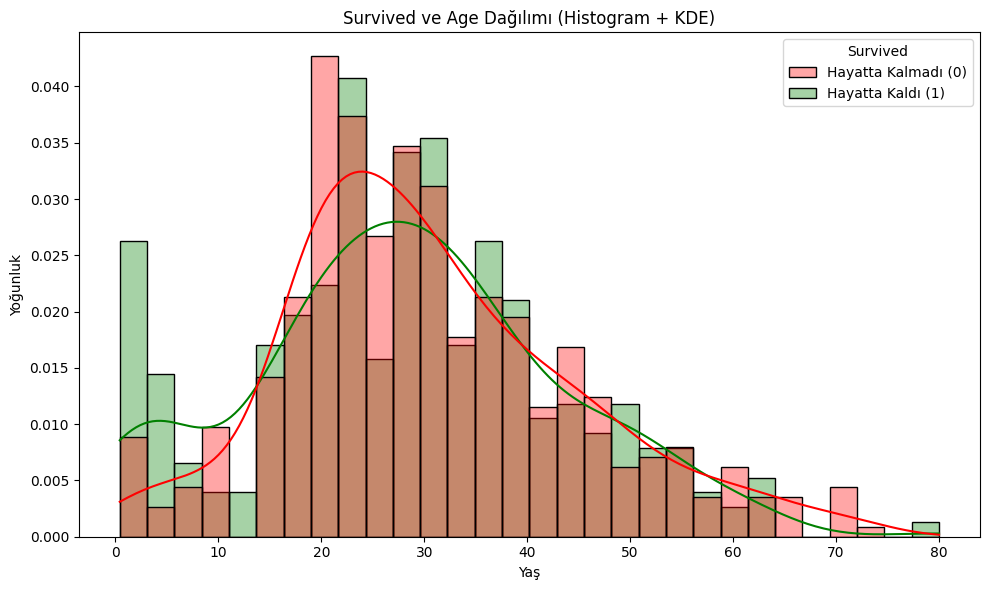

In [26]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    kde=True,
    bins=30,
    stat="density",
    common_norm=False,
    alpha=0.35,
    palette={0: "red", 1: "green"},
    hue_order=[0, 1]
)

plt.title("Survived ve Age Dağılımı (Histogram + KDE)")
plt.xlabel("Yaş")
plt.ylabel("Yoğunluk")

# Legend label'larını sabitle
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Survived")
    new_labels = ["Hayatta Kalmadı (0)", "Hayatta Kaldı (1)"]
    for text, new_label in zip(legend.texts, new_labels):
        text.set_text(new_label)

plt.tight_layout()
plt.show()

# Yaş grubuna göre survived analizi
age_survived = (
    df.groupby(["AgeGroup", "Survived"])
      .size()
      .reset_index(name="Count")
)

age_label_map = {1: "0-12", 2: "13-20", 3: "21-36", 4: "37-57", 5: "58-80"}
age_order = ["0-12", "13-20", "21-36", "37-57", "58-80"]

plot_df = age_survived.copy()
plot_df["AgeGroupLabel"] = plot_df["AgeGroup"].map(age_label_map)

pivot_df = (
    plot_df.pivot(index="AgeGroupLabel", columns="Survived", values="Count")
    .reindex(age_order)
    .fillna(0)
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=pivot_df.index,
        y=pivot_df[0],
        name="Hayatta Kalmadı (0)",
        marker_color="red",
        text=pivot_df[0].astype(int),
        textposition="outside"
    )
)

fig.add_trace(
    go.Bar(
        x=pivot_df.index,
        y=pivot_df[1],
        name="Hayatta Kaldı (1)",
        marker_color="green",
        text=pivot_df[1].astype(int),
        textposition="outside"
    )
)

fig.update_layout(
    title="Yaş Grubuna Göre Hayatta Kalma Durumu",
    xaxis_title="Yaş Grubu",
    yaxis_title="Yolcu Sayısı",
    barmode="group",
    template="plotly_white"
)

fig.show()

# Yüzde basında grafik
plot_df_pct = plot_df.copy()
plot_df_pct["Percent"] = (
    plot_df_pct["Count"] / plot_df_pct.groupby("AgeGroup")["Count"].transform("sum") * 100
)

plot_df_pct["AgeGroupLabel"] = plot_df_pct["AgeGroup"].map(age_label_map)

pivot_pct = (
    plot_df_pct.pivot(index="AgeGroupLabel", columns="Survived", values="Percent")
    .reindex(age_order)
    .fillna(0)
)

fig_pct = go.Figure()

fig_pct.add_trace(
    go.Bar(
        x=pivot_pct.index,
        y=pivot_pct[0],
        name="Hayatta Kalmadı (0) %",
        marker_color="red",
        text=[f"%{v:.1f}" for v in pivot_pct[0]],
        textposition="outside"
    )
)

fig_pct.add_trace(
    go.Bar(
        x=pivot_pct.index,
        y=pivot_pct[1],
        name="Hayatta Kaldı (1) %",
        marker_color="green",
        text=[f"%{v:.1f}" for v in pivot_pct[1]],
        textposition="outside"
    )
)

fig_pct.update_traces(
    customdata=pivot_df[0].astype(int).values,
    selector=dict(name="Hayatta Kalmadı (0) %")
)

fig_pct.update_traces(
    customdata=pivot_df[1].astype(int).values,
    selector=dict(name="Hayatta Kaldı (1) %")
)

fig_pct.update_layout(
    title="Yaş Grubuna Göre Hayatta Kalma Durumu (%)",
    xaxis_title="Yaş Grubu",
    yaxis_title="Yüzde (%)",
    yaxis=dict(range=[0, 100]),
    barmode="group",
    template="plotly_white"
)

fig_pct.show()

### Survived vs Is_Alone

In [27]:
# Survived vs Is_Alone (Adet + Yüzde, yan yana)
survived_alone = (
    df.groupby(["Is_Alone", "Survived"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=[0, 1], fill_value=0)
      .sort_index()
)

# Her Is_Alone grubu içinde yüzdeler
survived_alone_pct = survived_alone.div(survived_alone.sum(axis=1), axis=0) * 100

x_labels = survived_alone.index.map({0: "Grupla (0)", 1: "Yalnız (1)"})

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Adet Bazlı", "Yüzde Bazlı")
)

# --- Sol: Adet ---
fig.add_trace(
    go.Bar(
        x=x_labels,
        y=survived_alone[0],
        name="Hayatta Kalmadı (0)",
        marker_color="red",
        text=survived_alone[0],
        textposition="outside"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=x_labels,
        y=survived_alone[1],
        name="Hayatta Kaldı (1)",
        marker_color="green",
        text=survived_alone[1],
        textposition="outside"
    ),
    row=1, col=1
)

# --- Sağ: Yüzde ---
fig.add_trace(
    go.Bar(
        x=x_labels,
        y=survived_alone_pct[0],
        name="Hayatta Kalmadı (0) %",
        marker_color="red",
        text=[f"%{v:.1f}" for v in survived_alone_pct[0]],
        textposition="outside",
        customdata=survived_alone[0].values,
        hovertemplate="%{x}<br>Yüzde: %{y:.1f}%<br>Count: %{customdata}<extra></extra>",
        showlegend=False
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=x_labels,
        y=survived_alone_pct[1],
        name="Hayatta Kaldı (1) %",
        marker_color="green",
        text=[f"%{v:.1f}" for v in survived_alone_pct[1]],
        textposition="outside",
        customdata=survived_alone[1].values,
        hovertemplate="%{x}<br>Yüzde: %{y:.1f}%<br>Count: %{customdata}<extra></extra>",
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    title="Is_Alone Değişkenine Göre Hayatta Kalma Durumu (Adet ve Yüzde)",
    barmode="group",
    template="plotly_white",
    height=500
)

fig.update_xaxes(title_text="Is_Alone", row=1, col=1)
fig.update_yaxes(title_text="Yolcu Sayısı", row=1, col=1)

fig.update_xaxes(title_text="Is_Alone", row=1, col=2)
fig.update_yaxes(title_text="Yüzde (%)", range=[0, 100], row=1, col=2)
# Donut: Survived ve Is_Alone birlikte dağılım (dilimlerin üzerine yüzde yaz)
donut_labels = [
    "Grupla - Hayatta Kalmadı (0)",
    "Grupla - Hayatta Kaldı (1)",
    "Yalnız - Hayatta Kalmadı (0)",
    "Yalnız - Hayatta Kaldı (1)"
]

donut_values = [
    int(survived_alone.loc[0, 0]),
    int(survived_alone.loc[0, 1]),
    int(survived_alone.loc[1, 0]),
    int(survived_alone.loc[1, 1]),
]

fig_donut = go.Figure(
    data=[
        go.Pie(
            labels=donut_labels,
            values=donut_values,
            hole=0.55,
            textposition="inside",
            texttemplate="%{percent:.1%}",
            hovertemplate="%{label}<br>Yüzde: %{percent:.1%}<br>Count: %{value}<extra></extra>",
            marker=dict(colors=["#f5b1b1", "#a2e3ad", "#fa5252", "#2f9e44"])
        )
    ]
)

fig_donut.update_layout(
    title="Survived ve Is_Alone Dağılımı (Donut)",
    template="plotly_white",
    height=500
)

fig_donut.show()

fig.show()

Yalnız olanın hayatta kalma oranı çok daha düşüktür.

Grupla/Ailesiyle olanların hayatta kalma oranı daha yüksek.


### Survived vs Fare

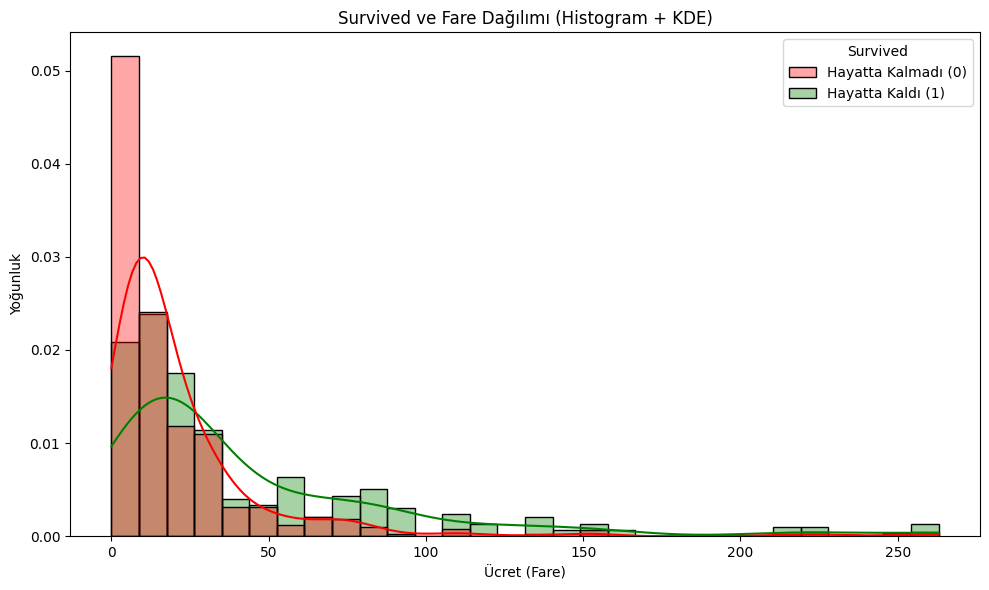

In [28]:
plt.figure(figsize=(10, 6))

ax = sns.histplot(
    data=df,
    x="Fare",
    hue="Survived",
    kde=True,
    bins=30,
    stat="density",
    common_norm=False,
    alpha=0.35,
    palette={0: "red", 1: "green"},
    hue_order=[0, 1]
)

plt.title("Survived ve Fare Dağılımı (Histogram + KDE)")
plt.xlabel("Ücret (Fare)")
plt.ylabel("Yoğunluk")

# Legend label'larını sabitle
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Survived")
    new_labels = ["Hayatta Kalmadı (0)", "Hayatta Kaldı (1)"]
    for text, new_label in zip(legend.texts, new_labels):
        text.set_text(new_label)

plt.tight_layout()
plt.show()

# Fare kategorisine göre survived analizi
fare_survived = (
    df.groupby(["Fare_Category", "Survived"])
      .size()
      .reset_index(name="Count")
)

fare_categories_sorted = sorted(df["Fare_Category"].dropna().unique())
fare_label_map = {cat: str(cat) for cat in fare_categories_sorted}
fare_order = [fare_label_map[c] for c in sorted(fare_label_map.keys())]

plot_df = fare_survived.copy()
plot_df["FareCategoryLabel"] = plot_df["Fare_Category"].map(fare_label_map)

pivot_df = (
    plot_df.pivot(index="FareCategoryLabel", columns="Survived", values="Count")
    .reindex(fare_order)
    .reindex(columns=[0, 1], fill_value=0)
    .fillna(0)
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=pivot_df.index,
        y=pivot_df[0],
        name="Hayatta Kalmadı (0)",
        marker_color="red",
        text=pivot_df[0].astype(int),
        textposition="outside"
    )
)

fig.add_trace(
    go.Bar(
        x=pivot_df.index,
        y=pivot_df[1],
        name="Hayatta Kaldı (1)",
        marker_color="green",
        text=pivot_df[1].astype(int),
        textposition="outside"
    )
)

fig.update_layout(
    title="Fare Kategorisine Göre Hayatta Kalma Durumu",
    xaxis_title="Fare Kategorisi",
    yaxis_title="Yolcu Sayısı",
    barmode="group",
    template="plotly_white"
)

fig.show()

# Yüzde bazında grafik
plot_df_pct = plot_df.copy()
plot_df_pct["Percent"] = (
    plot_df_pct["Count"] / plot_df_pct.groupby("Fare_Category")["Count"].transform("sum") * 100
)

plot_df_pct["FareCategoryLabel"] = plot_df_pct["Fare_Category"].map(fare_label_map)

pivot_pct = (
    plot_df_pct.pivot(index="FareCategoryLabel", columns="Survived", values="Percent")
    .reindex(fare_order)
    .reindex(columns=[0, 1], fill_value=0)
    .fillna(0)
)

fig_pct = go.Figure()

fig_pct.add_trace(
    go.Bar(
        x=pivot_pct.index,
        y=pivot_pct[0],
        name="Hayatta Kalmadı (0) %",
        marker_color="red",
        text=[f"%{v:.1f}" for v in pivot_pct[0]],
        textposition="outside"
    )
)

fig_pct.add_trace(
    go.Bar(
        x=pivot_pct.index,
        y=pivot_pct[1],
        name="Hayatta Kaldı (1) %",
        marker_color="green",
        text=[f"%{v:.1f}" for v in pivot_pct[1]],
        textposition="outside"
    )
)

fig_pct.update_traces(
    customdata=pivot_df[0].astype(int).values,
    selector=dict(name="Hayatta Kalmadı (0) %")
)

fig_pct.update_traces(
    customdata=pivot_df[1].astype(int).values,
    selector=dict(name="Hayatta Kaldı (1) %")
)

fig_pct.update_layout(
    title="Fare Kategorisine Göre Hayatta Kalma Durumu (%)",
    xaxis_title="Fare Kategorisi",
    yaxis_title="Yüzde (%)",
    yaxis=dict(range=[0, 100]),
    barmode="group",
    template="plotly_white"
)

fig_pct.show()

In [29]:
(df["Fare"] == 0).sum()

np.int64(15)

Yüksek ücret verenlerin hayatta kalma oranı daha yüksek.

### Survived vs Embarked

In [30]:
# df yoksa net uyarı ver
if "df" not in globals():
    raise NameError("df tanımlı değil. Lütfen df'nin oluşturulduğu hücreyi önce çalıştırın.")

# embarked_name_map yoksa varsayılan map kullan
if "embarked_name_map" not in globals():
    embarked_name_map = {
        "S": "Southampton (S)",
        "C": "Cherbourg (C)",
        "Q": "Queenstown (Q)"
    }

# Adet tablosu
survived_embarked = (
    df.dropna(subset=["Embarked", "Survived"])
      .groupby(["Embarked", "Survived"])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=[0, 1], fill_value=0)
)

# Sıra: map içindeki sırayı koru, ekstra kategori varsa sona ekle
embarked_order = [e for e in embarked_name_map.keys() if e in survived_embarked.index]
extra_cats = [e for e in survived_embarked.index if e not in embarked_order]
embarked_order = embarked_order + extra_cats

survived_embarked = survived_embarked.reindex(embarked_order, fill_value=0)

# Yüzde hesapları (text ve hover için)
survived_embarked_pct = survived_embarked.div(survived_embarked.sum(axis=1), axis=0) * 100
x_vals = [embarked_name_map.get(e, str(e)) for e in survived_embarked.index]

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=x_vals,
        y=survived_embarked[0],
        name="Hayatta Kalmadı (0)",
        marker_color="red",
        text=[f"%{v:.1f}" for v in survived_embarked_pct[0]],
        textposition="inside",
        customdata=survived_embarked[0].values,
        hovertemplate="%{x}<br>Hayatta Kalmadı<br>Yüzde: %{text}<br>Count: %{customdata}<extra></extra>",
    )
)

fig.add_trace(
    go.Bar(
        x=x_vals,
        y=survived_embarked[1],
        name="Hayatta Kaldı (1)",
        marker_color="green",
        text=[f"%{v:.1f}" for v in survived_embarked_pct[1]],
        textposition="inside",
        customdata=survived_embarked[1].values,
        hovertemplate="%{x}<br>Hayatta Kaldı<br>Yüzde: %{text}<br>Count: %{customdata}<extra></extra>",
    )
)

fig.update_layout(
    title="Embarked'e Göre Survived Dağılımı (%100 Stacked)",
    barmode="stack",
    barnorm="percent",   # her Embarked sütunu %100
    template="plotly_white",
    yaxis_title="Yüzde (%)",
    xaxis_title="Embarked",
    height=520
)


fig.show()


Cherbourg Limanından binenlerin hayatta kalma oranı daha yüksek. 

Bu değişken (Embarked) hayatta kalmayı etkileyemeyeceği için muhtemelen hayatta kalmayı etkileyecek diğer değişkenlerle ilişkisi vardır.


In [31]:
# Embarked vs Pclass (%100 yığılmış bar)
pclass_embarked_pct = (
    pd.crosstab(df["Embarked"], df["Pclass"], normalize="index") * 100
).reindex(embarked_order).reindex(columns=[1, 2, 3], fill_value=0)

x_vals = [embarked_name_map[e] for e in pclass_embarked_pct.index]

soft_colors = {
    1: "#A8DADC",  # soft mavi-yeşil
    2: "#FFD6A5",  # soft turuncu
    3: "#F88282",  # soft mor
}

fig = go.Figure()

for cls in [1, 2, 3]:
    vals = pclass_embarked_pct[cls].values
    fig.add_trace(
        go.Bar(
            x=x_vals,
            y=vals,
            name=f"{cls}. Sınıf",
            marker_color=soft_colors[cls],
            text=[f"%{v:.1f}" if v > 0 else "" for v in vals],
            textposition="inside",
            hovertemplate="Embarked: %{x}<br>Pclass: " + str(cls) + "<br>Yüzde: %{y:.1f}%<extra></extra>"
        )
    )

fig.update_layout(
    title="Embarked'e Göre Pclass Dağılımı (%100 Yığılmış)",
    barmode="stack",
    template="plotly_white",
    yaxis=dict(title="Yüzde (%)", range=[0, 100]),
    xaxis=dict(title="Embarked"),
    legend_title="Pclass"
)

fig.show()

Embarked değişkeninin hayatta kalma ile doğrudan bir ilişkisi yoktur; asıl ilişki 

Liman -> Bilet Sınıfı -> Hayatta Kalma şeklindedir. 

Limanlar, yolcuların sosyo-ekonomik statüleri (Pclass) hakkında bize dolaylı bilgi verir.

### Survived - Pclass - Sex - Age

In [32]:
# Survived - Pclass - Sex - Age için 3 donut'u güvenli şekilde üret
if "df" not in globals():
    raise NameError("df tanımlı değil. Lütfen veri yükleme hücrelerini önce çalıştırın.")

# Sex'e göre hayatta kalma oranı
sex_survival_rate = (df.groupby("Sex")["Survived"].mean() * 100).sort_values(ascending=False)

# Pclass'e göre hayatta kalma oranı
pclass_survival_rate = (df.groupby("Pclass")["Survived"].mean() * 100).sort_index()

# AgeGroup'a göre hayatta kalma oranı
if "AgeGroup" not in df.columns:
    raise NameError("AgeGroup sütunu yok. Lütfen AgeGroup oluşturan hücreyi önce çalıştırın.")

age_rate_raw = (df.dropna(subset=["AgeGroup"]).groupby("AgeGroup")["Survived"].mean() * 100)

if "age_label_map" in globals():
    age_labels = [age_label_map.get(k, str(k)) for k in age_rate_raw.index]
else:
    age_labels = [str(k) for k in age_rate_raw.index]

# 3 donut'u yan yana birleştir
fig_donuts = make_subplots(
    rows=1,
    cols=3,
    specs=[[{"type": "domain"}, {"type": "domain"}, {"type": "domain"}]],
    subplot_titles=(
        "Sex'e Göre Hayatta Kalma Oranı",
        "Pclass'e Göre Hayatta Kalma Oranı",
        "AgeGroup'a Göre Hayatta Kalma Oranı"
    ),
    horizontal_spacing=0.12
)

fig_donuts.add_trace(
    go.Pie(
        labels=sex_survival_rate.index,
        values=sex_survival_rate.values,
        hole=0.55,
        texttemplate="%{label}<br>%{value:.1f}",
        textposition="inside",
        marker=dict(colors=["#ff69b4", "#1f77b4"])
    ),
    row=1,
    col=1
)

fig_donuts.add_trace(
    go.Pie(
        labels=[str(v) for v in pclass_survival_rate.index],
        values=pclass_survival_rate.values,
        hole=0.55,
        texttemplate="Pclass %{label}<br>%{value:.1f}",
        textposition="inside",
        marker=dict(colors=["#2ca02c", "#ff7f0e", "#d62728"])
    ),
    row=1,
    col=2
)

fig_donuts.add_trace(
    go.Pie(
        labels=age_labels,
        values=age_rate_raw.values,
        hole=0.55,
        texttemplate="%{label}<br>%{value:.1f}",
        textposition="inside",
        marker=dict(colors=["#8dd3c7", "#ffffb3", "#bebada", "#fb8072", "#80b1d3"])
    ),
    row=1,
    col=3
)

fig_donuts.update_layout(
    template="plotly_white",
    height=520,
    width=1400,
    margin=dict(l=30, r=30, t=90, b=20)
)

fig_donuts.show()

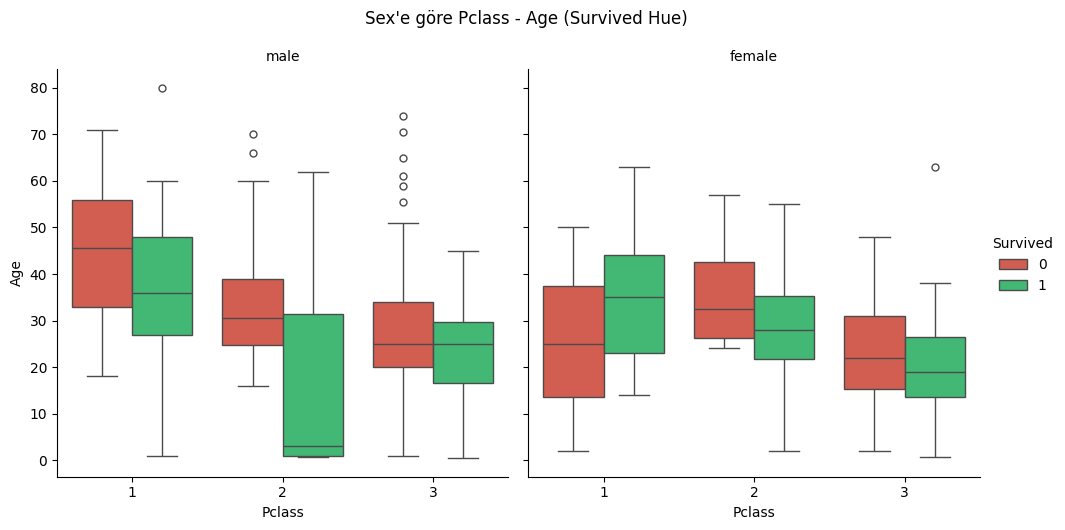

In [33]:
survived_palette = {0: "#e74c3c", 1: "#2ecc71"}

g = sns.catplot(
    data=df,
    x="Pclass",
    y="Age",
    hue="Survived",
    col="Sex",
    kind="box",
    palette=survived_palette,
    height=5,
    aspect=1
)

g.set_axis_labels("Pclass", "Age")
g.set_titles("{col_name}")
g.fig.suptitle("Sex'e göre Pclass - Age (Survived Hue)", y=1.05)

plt.show()

2. sınıftaki erkeklerin neredeyse tamamı ölmüş, bu gruptan kurtulan erkeklerin tamamı 0-15 yaş arası çocuklardır. 

3. Sınıf Kadınlar yani alt sosyo-ekonomik sınıftaki kadınlarda yaş ilerledikçe hayatta kalma şansı istatistiksel olarak düşmektedir. Hayatta kalmayı başaran kadınlar genellikle fiziksel olarak daha gençtir.



In [34]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,Fare_Category,Is_Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,4,4,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3,2,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3,4,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3,2,1


In [35]:

# Korelasyon matrisi
numerical_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Is_Alone']
corr_matrix    = df[numerical_cols].corr().round(3)
survived_corr  = corr_matrix['Survived'].sort_values(ascending=True)

# ── FİGÜR 1: Tam Korelasyon Heatmap ──────────────────────────────────────
labels = corr_matrix.columns.tolist()
z      = corr_matrix.values.tolist()

text = [[f"{corr_matrix.iloc[i, j]:.3f}" for j in range(len(labels))]
        for i in range(len(labels))]

fig1 = go.Figure(go.Heatmap(
    z=z,
    x=labels,
    y=labels,
    text=text,
    texttemplate="%{text}",
    textfont=dict(size=13, color="black"),
    colorscale=[
        [0.0, "#e74c3c"],
        [0.5, "#f9f9f9"],
        [1.0, "#2ecc71"]
    ],
    zmin=-1, zmax=1,
    colorbar=dict(
        title=dict(text="Korelasyon", font=dict(size=13)),
        tickfont=dict(size=12),
        thickness=16
    )
))

fig1.update_layout(
    title=dict(
        text="Korelasyon Matrisi — Tüm Sayısal Değişkenler",
        x=0.5, xanchor="center", y=0.97,
        font=dict(size=20, color="#2c3e50", family="Arial Black")
    ),
    height=520,
    paper_bgcolor="white",
    plot_bgcolor="white",
    font=dict(size=13, family="Arial"),
    xaxis=dict(tickfont=dict(size=13), side="bottom"),
    yaxis=dict(tickfont=dict(size=13), autorange="reversed"),
    margin=dict(t=100, b=60, l=80, r=60)
)
fig1.show()

# ── FİGÜR 2: Survived ile Korelasyon — Yatay Bar ─────────────────────────
bar_colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in survived_corr.values]

fig2 = go.Figure(go.Bar(
    x=survived_corr.values,
    y=survived_corr.index.tolist(),
    orientation="h",
    marker_color=bar_colors,
    marker_line=dict(color="#2c3e50", width=1.2),
    text=[f"{v:+.3f}" for v in survived_corr.values],
    textposition="outside",
    textfont=dict(size=13, color="#2c3e50")
))

fig2.add_vline(x=0, line_color="#2c3e50", line_width=2, line_dash="dash")

fig2.update_layout(
    title=dict(
        text="Survived ile Korelasyonlar (Sıralı)",
        x=0.5, xanchor="center", y=0.95,
        font=dict(size=20, color="#2c3e50", family="Arial Black")
    ),
    height=440,
    paper_bgcolor="white",
    plot_bgcolor="#f8f9fa",
    font=dict(size=13, family="Arial"),
    xaxis=dict(
        title="Korelasyon Katsayısı", title_font_size=13,
        tickfont=dict(size=13),
        showgrid=True, gridcolor="#ddd", gridwidth=1,
        range=[-0.45, 0.45]
    ),
    yaxis=dict(tickfont=dict(size=13)),
    showlegend=False,
    margin=dict(t=100, b=70, l=110, r=80)
)
fig2.show()

### Survived Korelasyonları — Özet Tablo

| Değişken | Skor | Yön | Yorum |
|---|---:|---|---|
| Survived | `+1.000` | Pozitif | Hedef değişken — kendisiyle korelasyon 1.0 |
| Fare | `+0.262` | Pozitif | Ücretli bilet → 1. sınıf → hayatta kalma artar |
| Parch | `+0.082` | Pozitif / Zayıf | Küçük aile olmak küçük bir avantaj sağlar |
| SibSp | `-0.033` | Negatif / Zayıf | Çok kardeş/eş → kargaşada kaybolma riski |
| Age | `-0.079` | Negatif / Zayıf | Yaş ile hayatta kalma arasında zayıf ilişki |
| Is_Alone | `-0.205` | Negatif | Yalnız olanların hayatta kalma oranı daha düşük |
| Pclass | `-0.334` | Negatif | Alt sınıf olmak (3) hayatta kalmayı azaltır |


<Figure size 200x200 with 0 Axes>

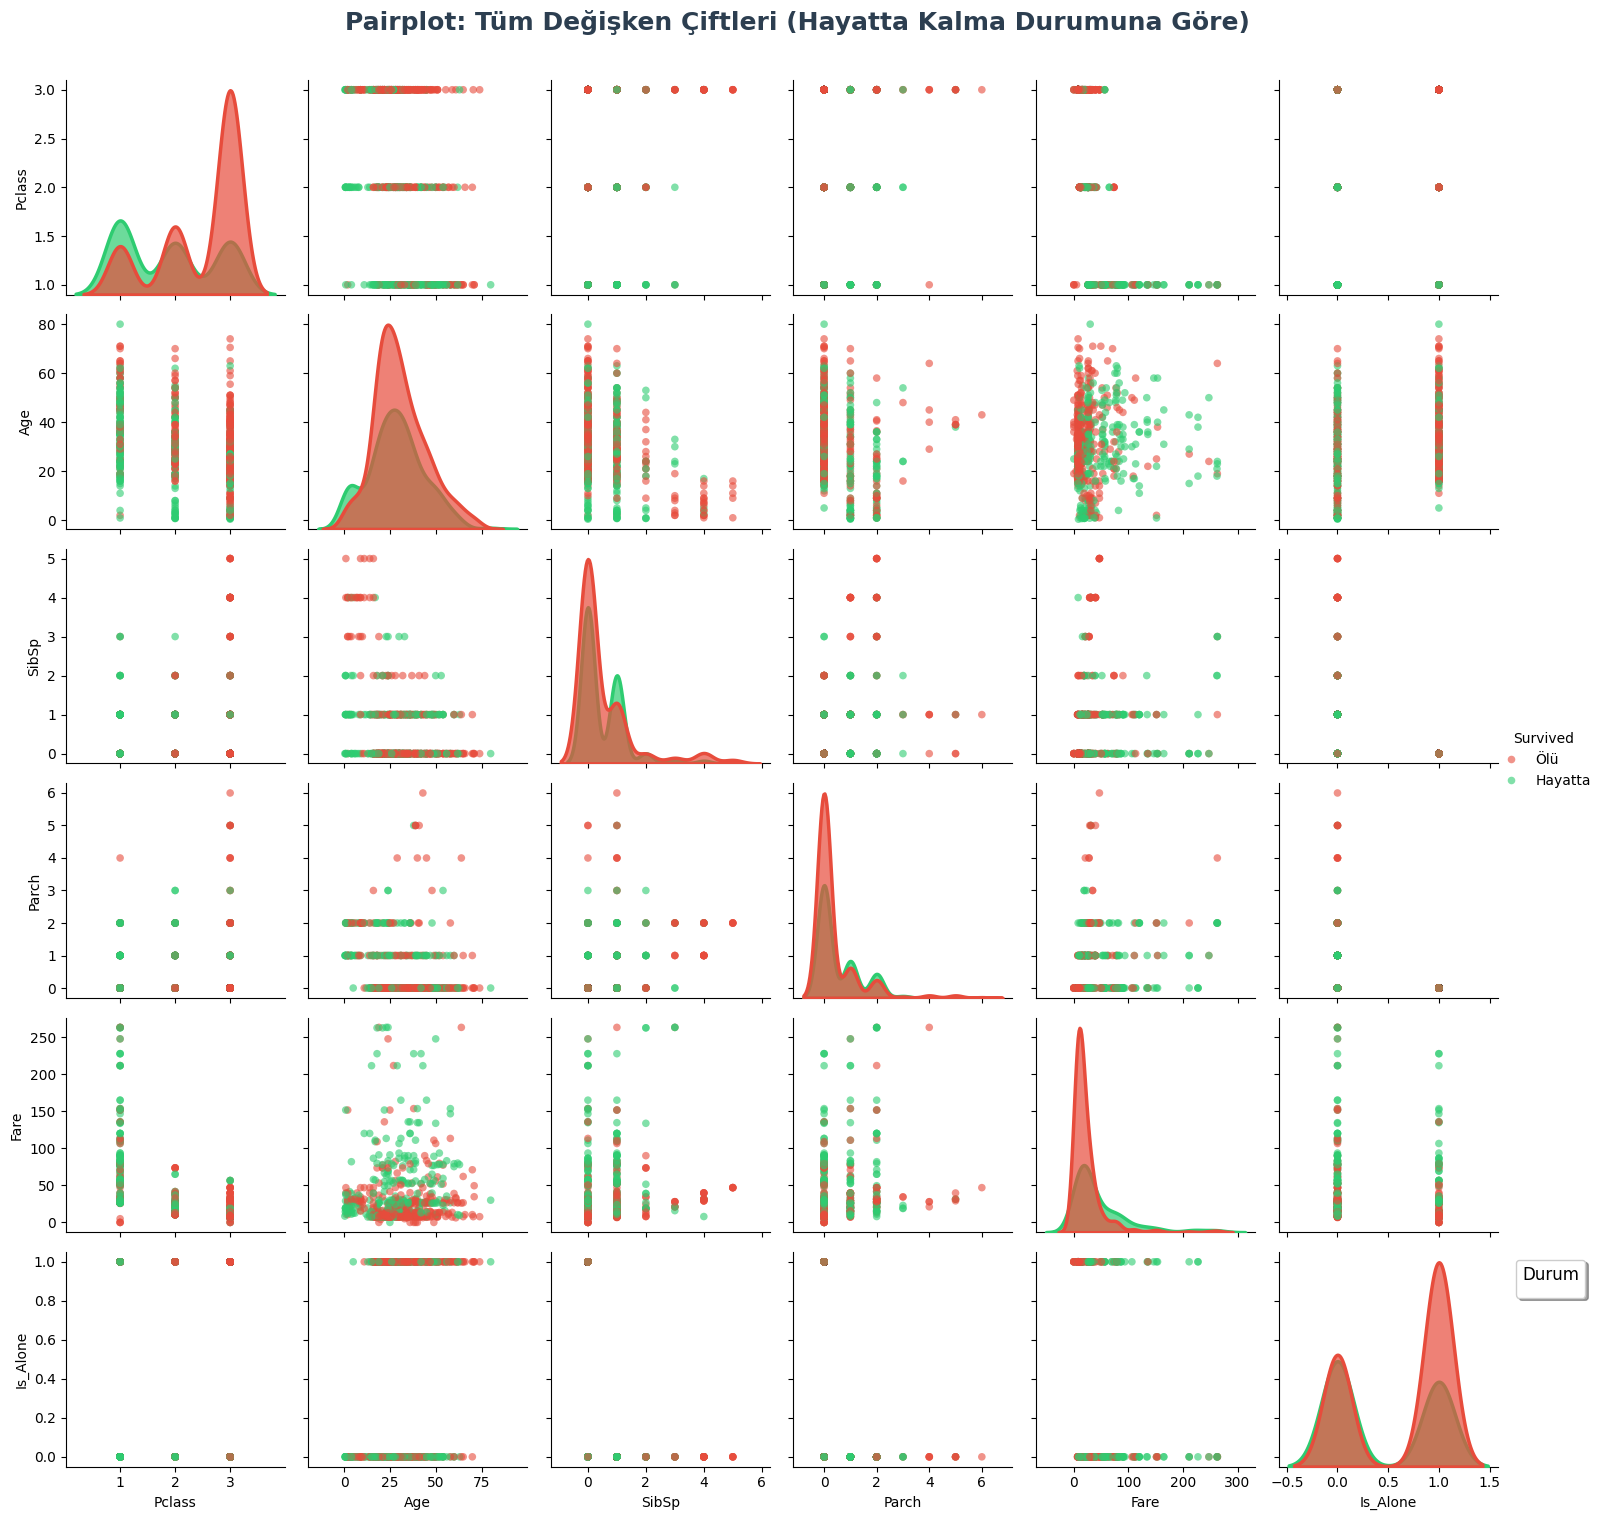

In [36]:
# Pairplot için veri hazırlama (Sadece sayısal değişkenler + Survived)
pairplot_data = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Is_Alone']].dropna()
pairplot_data['Survived'] = pairplot_data['Survived'].map({0: 'Ölü', 1: 'Hayatta'})

# Pairplot
plt.figure(figsize=(2, 2))  # Küçük figure (pairplot kendi boyutunu ayarlar)
pairplot_fig = sns.pairplot(
    pairplot_data,
    hue='Survived',
    palette={'Ölü': '#e74c3c', 'Hayatta': '#2ecc71'},
    diag_kind='kde',  # Diagonal'da KDE
    plot_kws={'alpha': 0.6, 'edgecolor': 'none', 's': 30},
    diag_kws={'linewidth': 2.5, 'alpha': 0.7}
)

# Başlık ekle
pairplot_fig.fig.suptitle('Pairplot: Tüm Değişken Çiftleri (Hayatta Kalma Durumuna Göre)', 
                          fontsize=18, fontweight='bold', color='#2c3e50', y=1.01)

# Legend konumunu düzenle
plt.legend(title='Durum', bbox_to_anchor=(1.05, 1), loc='upper left', 
           fontsize=11, title_fontsize=12, frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.show()


* Pclass'ın hayatta kalma ile ilişkisinin yüksek olduğunu korelasyondandan gördük.

    Burada da Pclass ve Is_Alone sütunlarının ilişkisini görüyoruz. 1. sınıfların bir çoğu kurtulmuş 3. sınıfların bir çoğu ölmüş ancak 2. sınıflarda yaşama oranına yalnız olma etki etmiş ve yalnız olmayanlar yalnız olanlara göre daha çok hayatta kalmış.

* Is_Alone ve Fare sütunlarına bakınca ise yalnız Düşük ücret ödeyenlerin yaşama oranının daha az olduğunu görmüştük.

    Burada ise görüyoruz ki düşük ücret ödeseler bile yalnız olmayanlar yalnız olaranlara göre daha çok hayatta kalmış.

* Fare ve Pclass sütunalrına bakınca yüksek ücret ödeyenlerin kesinlikle 1. sınıf olduğunu çok net görüyoruz ve yüksek ücret ödeyenlerin bir çoğunun hayatta kaldığı çok net gözüküyor

* Fare ve Age sütunlarına bakınca ise düşük ücret ödeyenlerin bir çoğunun öldüğü ancak age'in grafik başlangıcı çok net yeşille başladığı sonra kırmızı/karışık olduğu görülüyor.

    Bu da demektir ki düşük ücret ödeseler bile çocukların kurtulma oranı daha yüksek.

* Parch ve SibSp sütunlarına bakınca ise çok kalabalık olanların ölüm oranının arttığını görüyoruz. Yani yalnızlık tek başına bir belirleyici değil yanındaki kişi sayısı da kurtulmanda önemli.

In [37]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup,Fare_Category,Is_Alone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,4,4,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3,2,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3,4,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3,2,1


In [38]:
df.isnull().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age              177
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            686
Embarked           2
AgeGroup         177
Fare_Category      0
Is_Alone           0
dtype: int64

# Machine Learning

In [39]:
df_model = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Is_Alone', 'AgeGroup', 'Fare_Category']].copy()

In [40]:
X = df_model.drop('Survived', axis=1)

y = df_model['Survived']

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

Eksik Verileri Tamamlama

**Age (Yaş):** Sadece X_train verisinin sabit bir ortalaması yerine; **Pclass** (Sınıf) ve **Sex** (Cinsiyet) değişkenlerine göre gruplandırılarak (**Groupby**) bu grupların kendi ortalamalarıyla tamamlanmalı. Bu değerle hem X_train hem de X_test içindeki boş yaşlara doldur.

**AgeGroup (Yaş Grubu):** Age sütunundaki eksikler dolduğu için, AgeGroup sütununu doldurulmuş yeni yaşlara göre tekrar çalıştır/güncelle.

**Embarked (Liman):** Sadece X_train içindeki en çok tekrar eden limanı (Mod) bul ve hem Train hem Test'teki eksiklere yaz.

In [43]:
freq_port = X_train['Embarked'].mode()[0]

X_train['Embarked'] = X_train['Embarked'].fillna(freq_port)
X_test['Embarked'] = X_test['Embarked'].fillna(freq_port)


age_means = X_train.groupby(['Pclass', 'Sex'])['Age'].mean()

def fill_age(row):
    if pd.isnull(row['Age']):
        return age_means[row['Pclass'], row['Sex']]
    return row['Age']

X_train['Age'] = X_train.apply(fill_age, axis=1)
X_test['Age'] = X_test.apply(fill_age, axis=1)

yas_araliklari = [0, 12, 20, 36, 57, 80]
kategoriler = [1, 2, 3, 4, 5]

X_train['AgeGroup'] = pd.cut(X_train['Age'], bins=yas_araliklari, labels=kategoriler, include_lowest=True)

X_test['AgeGroup'] = pd.cut(X_test['Age'], bins=yas_araliklari, labels=kategoriler, include_lowest=True)

print("Train Seti AgeGroup Boş Veri Sayısı:", X_train['AgeGroup'].isnull().sum())
print("Test Seti AgeGroup Boş Veri Sayısı:", X_test['AgeGroup'].isnull().sum())

print("Train Seti Eksik Veriler:\n", X_train.isnull().sum())

Train Seti AgeGroup Boş Veri Sayısı: 0
Test Seti AgeGroup Boş Veri Sayısı: 0
Train Seti Eksik Veriler:
 Pclass           0
Sex              0
Age              0
SibSp            0
Parch            0
Fare             0
Embarked         0
Is_Alone         0
AgeGroup         0
Fare_Category    0
dtype: int64


In [44]:
from sklearn.preprocessing import RobustScaler, StandardScaler
from lazypredict.Supervised import LazyClassifier

robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

X_train['Fare'] = robust_scaler.fit_transform(X_train[['Fare']])
X_train[['Age', 'SibSp', 'Parch']] = standard_scaler.fit_transform(X_train[['Age', 'SibSp', 'Parch']])

X_test['Fare'] = robust_scaler.transform(X_test[['Fare']])
X_test[['Age', 'SibSp', 'Parch']] = standard_scaler.transform(X_test[['Age', 'SibSp', 'Parch']])

clf_scaled = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models_scaled, predictions_scaled = clf_scaled.fit(X_train, X_test, y_train, y_test)

print(models_scaled)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 267, number of negative: 443
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 215
[LightGBM] [Info] Number of data points in the train set: 710, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376056 -> initscore=-0.506321
[LightGBM] [Info] Start training from score -0.506321
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

In [45]:
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()

X_train['Sex'] = le_sex.fit_transform(X_train['Sex'])
X_test['Sex'] = le_sex.transform(X_test['Sex'])

In [46]:
from sklearn.preprocessing import OneHotEncoder

ohe_embarked = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

embarked_encoded_train = ohe_embarked.fit_transform(X_train[['Embarked']])

embarked_cols = [f'Embarked_{cat}' for cat in ohe_embarked.categories_[0]]

embarked_train_df = pd.DataFrame(embarked_encoded_train, columns=embarked_cols, index=X_train.index)
X_train = pd.concat([X_train, embarked_train_df], axis=1)

embarked_encoded_test = ohe_embarked.transform(X_test[['Embarked']])
embarked_test_df = pd.DataFrame(embarked_encoded_test, columns=embarked_cols, index=X_test.index)
X_test = pd.concat([X_test, embarked_test_df], axis=1)

X_train = X_train.drop('Embarked', axis=1)
X_test = X_test.drop('Embarked', axis=1)

print("One-Hot Encoded Embarked Sütunları:")
print(embarked_cols)
print("\nX_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("\nX_train ilk 5 satır:")
print(X_train.head())

One-Hot Encoded Embarked Sütunları:
['Embarked_C', 'Embarked_Q', 'Embarked_S']

X_train Shape: (710, 12)
X_test Shape: (178, 12)

X_train ilk 5 satır:
     Pclass  Sex   Age  SibSp  Parch  Fare  Is_Alone AgeGroup Fare_Category  \
228       2    1 -0.91  -0.46  -0.46 -0.06         1        2             2   
161       2    0  0.78  -0.46  -0.46  0.06         1        4             3   
18        3    0  0.09   0.42  -0.46  0.15         0        3             3   
598       1    1  1.47   0.42  -0.46  1.84         0        4             4   
230       1    0  0.40   0.42  -0.46  2.99         0        3             4   

     Embarked_C  Embarked_Q  Embarked_S  
228        0.00        0.00        1.00  
161        0.00        0.00        1.00  
18         0.00        0.00        1.00  
598        1.00        0.00        0.00  
230        0.00        0.00        1.00  


In [47]:
import lazypredict

from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 267, number of negative: 443
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000418 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 217
[LightGBM] [Info] Number of data points in the train set: 710, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376056 -> initscore=-0.506321
[LightGBM] [Info] Start training from score -0.506321
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [48]:
!pip install ipywidgets

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Veriyi float'a çevir (category dtype sorununu önlemek için)
X_train_f = X_train.astype(float)
X_test_f = X_test.astype(float)

param_grids = {
    "LGBMClassifier": {
        "model": LGBMClassifier(verbose=-1, random_state=42),
        "params": {
            "n_estimators": [100, 200, 500, 1000],
            "max_depth": [3, 5, 7, 10, -1],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "num_leaves": [15, 31, 63, 127],
            "min_child_samples": [5, 10, 20, 50],
            "subsample": [0.6, 0.8, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
        }
    },
    "XGBClassifier": {
        "model": XGBClassifier(eval_metric="logloss", random_state=42),
        "params": {
            "n_estimators": [100, 200, 500, 1000],
            "max_depth": [3, 5, 7, 10],
            "learning_rate": [0.01, 0.05, 0.1, 0.2],
            "subsample": [0.6, 0.8, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
            "gamma": [0, 0.1, 0.3, 0.5],
            "min_child_weight": [1, 3, 5, 7],
        }
    },
    "RandomForestClassifier": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200, 500, 1000],
            "max_depth": [5, 8, 10, 15, None],
            "max_features": ["sqrt", "log2"],
            "min_samples_split": [2, 5, 8, 12],
            "min_samples_leaf": [1, 2, 4],
        }
    },
}

results = {}

for name, cfg in param_grids.items():
    print(f"\n{'='*60}")
    print(f" {name} - Hyperparameter Tuning")
    print(f"{'='*60}")

    search = RandomizedSearchCV(
        estimator=cfg["model"],
        param_distributions=cfg["params"],
        n_iter=50,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        random_state=42,
        verbose=0,
    )
    search.fit(X_train_f, y_train)

    best_model = search.best_estimator_
    train_acc = accuracy_score(y_train, best_model.predict(X_train_f))
    test_acc = accuracy_score(y_test, best_model.predict(X_test_f))

    results[name] = {
        "best_params": search.best_params_,
        "best_cv_score": search.best_score_,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "best_model": best_model,
    }

    print(f"  Best CV Score  : {search.best_score_:.4f}")
    print(f"  Train Accuracy : {train_acc:.4f}")
    print(f"  Test Accuracy  : {test_acc:.4f}")
    print(f"  Best Params    : {search.best_params_}")

# Özet tablo
print(f"\n\n{'='*60}")
print(" ÖZET TABLO")
print(f"{'='*60}")
print(f"{'Model':<30} {'CV Score':>10} {'Train Acc':>10} {'Test Acc':>10}")
print("-" * 60)
for name, res in sorted(results.items(), key=lambda x: x[1]["test_accuracy"], reverse=True):
    print(f"{name:<30} {res['best_cv_score']:>10.4f} {res['train_accuracy']:>10.4f} {res['test_accuracy']:>10.4f}")


 LGBMClassifier - Hyperparameter Tuning
  Best CV Score  : 0.8380
  Train Accuracy : 0.8944
  Test Accuracy  : 0.8539
  Best Params    : {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

 XGBClassifier - Hyperparameter Tuning
  Best CV Score  : 0.8507
  Train Accuracy : 0.9141
  Test Accuracy  : 0.8539
  Best Params    : {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 1.0}

 RandomForestClassifier - Hyperparameter Tuning
  Best CV Score  : 0.8408
  Train Accuracy : 0.9085
  Test Accuracy  : 0.8427
  Best Params    : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}


 ÖZET TABLO
Model                            CV Score  Train Acc   Test Acc
------------------------------------------------------------
LGBMClassifier                     0.83

### Model Karşılaştırma Sonuçları

| Model | CV Score | Train Acc | Test Acc |
|---|---:|---:|---:|
| LGBMClassifier | 0.8380 | 0.8944 | **0.8539** |
| XGBClassifier | **0.8507** | 0.9141 | **0.8539** |
| RandomForestClassifier | 0.8408 | 0.9085 | 0.8427 |

- **En yüksek Test Acc:** LGBMClassifier ve XGBClassifier (eşit: **0.8539**)
- **En yüksek CV Score:** XGBClassifier (**0.8507**)

En iyi XGBClassifier gibi dursa da 

hem train test arasındaki farkın LGBMClassifier'e göre daha yüksek olması 

hem de hızı dolayısıyla bu model için **LGBMClassifier daha iyi bir seçenek olacaktır.**

In [58]:
import time
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lgbm_final = LGBMClassifier(
    subsample=0.8,
    num_leaves=127,
    n_estimators=200,
    min_child_samples=50,
    max_depth=-1,
    learning_rate=0.05,
    colsample_bytree=0.8,
    verbose=-1,
    random_state=42
)

start = time.time()
lgbm_final.fit(X_train_f, y_train)
y_pred = lgbm_final.predict(X_test_f)
elapsed = time.time() - start

print(f"Eğitim + Tahmin Süresi: {elapsed:.4f} saniye")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['Hayatta Kalmadı (0)', 'Hayatta Kaldı (1)'])}")

Eğitim + Tahmin Süresi: 0.5104 saniye

Accuracy: 0.8539

Confusion Matrix:
[[97  9]
 [17 55]]

Classification Report:
                     precision    recall  f1-score   support

Hayatta Kalmadı (0)       0.85      0.92      0.88       106
  Hayatta Kaldı (1)       0.86      0.76      0.81        72

           accuracy                           0.85       178
          macro avg       0.86      0.84      0.85       178
       weighted avg       0.85      0.85      0.85       178



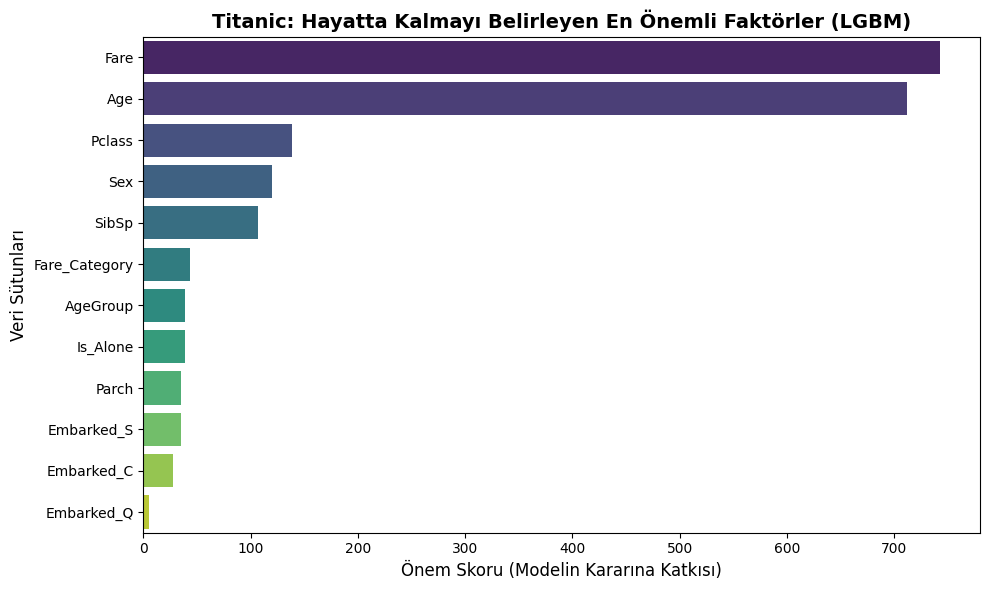

In [59]:
onem_dereceleri = pd.DataFrame({
    'Özellikler': X_train.columns,
    'Önem Skoru': lgbm_final.feature_importances_
})

onem_dereceleri = onem_dereceleri.sort_values(by='Önem Skoru', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Skoru', y='Özellikler', data=onem_dereceleri, palette='viridis')

plt.title('Titanic: Hayatta Kalmayı Belirleyen En Önemli Faktörler (LGBM)', fontsize=14, fontweight='bold')
plt.xlabel('Önem Skoru (Modelin Kararına Katkısı)', fontsize=12)
plt.ylabel('Veri Sütunları', fontsize=12)
plt.tight_layout()

plt.show()